In [15]:
import pandas as pd

In [17]:
df = pd.read_csv('Consumer_Complaints.csv')

In [18]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,3/12/2014,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,3/17/2014,Closed with explanation,Yes,No,759217
1,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10/5/2016,Closed with explanation,Yes,No,2141773
2,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/2016,Closed with explanation,Yes,No,2163100
3,6/8/2014,Credit card,NaN,Bankruptcy,NaN,NaN,NaN,AMERICAN EXPRESS COMPANY,ID,83854,Older American,NaN,Web,6/10/2014,Closed with explanation,Yes,Yes,885638
4,9/13/2014,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,NaN,NaN,"CITIBANK, N.A.",VA,23233,NaN,NaN,Web,9/13/2014,Closed with explanation,Yes,Yes,1027760


In [19]:
df.columns.tolist()

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Consumer consent provided?',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Consumer disputed?',
 'Complaint ID']

In [23]:
df.shape

(903983, 18)

In [25]:
df = df.rename(columns={
    'Date received': 'date_received',
    'Product': 'product',
    'Sub-product': 'subproduct',
    'Issue': 'issue',
    'Sub-issue': 'subissue',
    'Consumer complaint narrative': 'complaint_text',
    'Company public response': 'company_public_response',
    'Company': 'company_name',
    'State': 'state',
    'ZIP code': 'zip_code',
    'Tags': 'tags',
    'Consumer consent provided?': 'consumer_consent_provided',
    'Submitted via': 'submitted_via',
    'Date sent to company': 'date_sent_to_company',
    'Company response to consumer': 'company_response_to_consumer',
    'Timely response?': 'timely_response',
    'Consumer disputed?': 'consumer_disputed',
    'Complaint ID': 'complaint_id'
})


In [27]:
df.columns.tolist()

['date_received',
 'product',
 'subproduct',
 'issue',
 'subissue',
 'complaint_text',
 'company_public_response',
 'company_name',
 'state',
 'zip_code',
 'tags',
 'consumer_consent_provided',
 'submitted_via',
 'date_sent_to_company',
 'company_response_to_consumer',
 'timely_response',
 'consumer_disputed',
 'complaint_id']

In [31]:
df['complaint_text'].notna().sum()

199970

In [33]:
df_nlp = df[df['complaint_text'].notna()].copy()

In [35]:
df_nlp.shape

(199970, 18)

In [37]:
df_nlp = df_nlp[df_nlp['complaint_text'].str.strip().ne('')]

In [39]:
df_nlp.shape

(199970, 18)

In [55]:
import re

def cleanText(text):
    text = text.lower()
    text = re.sub(r'\s+' , ' ', text)
    text= re.sub('r\n+' , ' ', text)
    return text.strip()

In [57]:
boilerplate_patterns = [
    r'thank you for your (help|assistance)',
    r'i am writing (this )?complaint',
    r'please help',
    r'please assist'
]

def remove_boilerplates(text):
    for pattern in boilerplate_patterns:
        text = re.sub(pattern , '', text);
    return text.strip()

In [59]:
df_nlp['clean_text'] = df_nlp['complaint_text'].apply(cleanText)

In [61]:
df_nlp['clean_text'] = df_nlp['complaint_text'].apply(remove_boilerplates)

In [78]:
df_nlp['text_len'] = df_nlp['complaint_text'].str.split().apply(len)

In [80]:
df_nlp.head()

,date_received,product,subproduct,issue,subissue,complaint_text,company_public_response,company_name,state,zip_code,...,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed,complaint_id,clean_text,.text_len,text_len
1,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,...,Consent provided,Web,10/5/2016,Closed with explanation,Yes,No,2141773,I have outdated information on my credit repor...,34,34
2,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,...,Consent provided,Web,10/20/2016,Closed with explanation,Yes,No,2163100,I purchased a new car on XXXX XXXX. The car de...,394,394
7,6/15/2015,Credit reporting,NaN,Credit reporting company's investigation,Inadequate help over the phone,An account on my credit report has a mistaken ...,Company chooses not to provide a public response,Experian Information Solutions Inc.,VA,224XX,...,Consent provided,Web,6/15/2015,Closed with explanation,Yes,No,1420702,An account on my credit report has a mistaken ...,212,212
12,2/3/2016,Debt collection,"Other (i.e. phone, health club, etc.)",Disclosure verification of debt,Not given enough info to verify debt,This company refuses to provide me verificatio...,NaN,"The CBE Group, Inc.",TX,752XX,...,Consent provided,Web,2/3/2016,Closed with explanation,Yes,Yes,1772196,This company refuses to provide me verificatio...,25,25
16,2/17/2016,Debt collection,Credit card,Improper contact or sharing of info,Talked to a third party about my debt,This complaint is in regards to Square Two Fin...,Company has responded to the consumer and the ...,SQUARETWO FINANCIAL CORPORATION,NE,693XX,...,Consent provided,Web,3/4/2016,Closed with explanation,Yes,Yes,1790634,This complaint is in regards to Square Two Fin...,309,309


In [84]:
df_nlp = df_nlp[df_nlp['text_len']>=20]

In [86]:
df_nlp.shape

(193297, 21)

In [88]:
df_nlp = df_nlp.drop_duplicates(subset='clean_text')

In [90]:
df_nlp.shape

(189109, 21)

In [100]:
df_nlp = df_nlp.drop(columns=['.text_len'])

In [102]:
df_nlp['clean_text'].sample(10, random_state=42).tolist()

['This account was sent to collections and judged upon where it was paid in full. There is a balance of {$21.00} showing. It should be {$0.00}.',
 "I have  XXXX  bankruptcies on my record that are not mine I 've sent in letters showed proof they advised they verify through  XXXX   XXXX  who advised they have NO RECORDS on file for me. I have filed many many disputes now it will be here and better business bureau",
 "I contacted by XXXX XXXX regarding an XXXX account balance that I disputed with XXXX, this past XXXX 2015. I had previously made a partial payment to RGE days before I was contacted by XXXX XXXX. When I spoke to the customer service rep at XXXX XXXX, I gave them all the information to debit my checking account for the remaining balance. I was told that they would first have to verify with RGE of the amount that I had already paid, and it might take as long as 30 days to confirm. They would then debit my account for the balance. I questioned whether the collection informatio

In [114]:

df_nlp['date_received'] = pd.to_datetime(
    df_nlp['date_received'],
    errors='coerce'
)


In [116]:
df_nlp['date_received'].isna().sum()

0

In [124]:
df_nlp['year'] = df_nlp['date_received'].dt.year
df_nlp['month'] = df_nlp['date_received'].dt.to_period('M')
df_nlp['week'] = df_nlp['date_received'].dt.to_period('W')

In [130]:
df_nlp[['year','month','week']].head()

,year,month,week
1,2016,2016-10,2016-09-26/2016-10-02
2,2016,2016-10,2016-10-17/2016-10-23
7,2015,2015-06,2015-06-15/2015-06-21
12,2016,2016-02,2016-02-01/2016-02-07
16,2016,2016-02,2016-02-15/2016-02-21


In [132]:
df_nlp = df_nlp.drop(columns=['day'])

In [136]:
df_nlp['year'].value_counts().sort_index()

year
2015    51935
2016    74089
2017    63085
Name: count, dtype: int64

<Axes: title={'center': 'Complaints per Month'}, xlabel='month'>

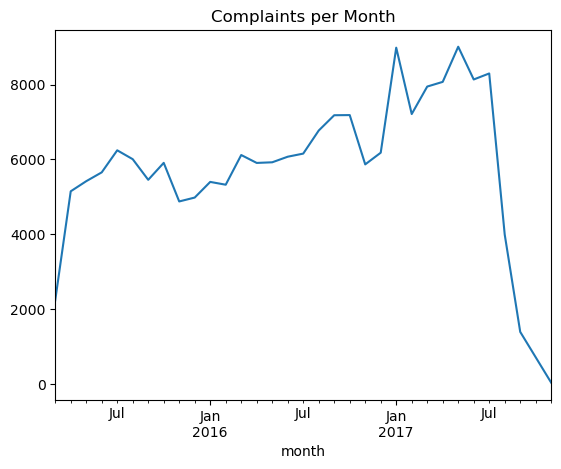

In [140]:
complaints_per_month = df_nlp.groupby('month').size()
complaints_per_month.plot(title = 'Complaints per Month')